# Real-Time Cyber-Aggression Detection
## Naive Bayes + VADER Training Notebook
### Pamantasan ng Cabuyao — BSCS Thesis 2026
**Researchers:** Damian, Garcia, Palisoc, Regidor

---
This notebook trains the Naive Bayes classifier used in the CAD Shield Chrome Extension.
It covers:
1. Dataset Loading & Exploration
2. Text Preprocessing
3. Model Training
4. Evaluation (Precision, Recall, F1-Score)
5. Visualizations
6. Saving the Model

## Cell 1 — Install & Import Libraries

In [1]:
# Install required libraries (run once)
import subprocess
subprocess.run(['pip', 'install', 'pandas', 'numpy', 'scikit-learn', 'nltk',
                'vaderSentiment', 'joblib', 'matplotlib', 'seaborn', 'wordcloud'], 
               capture_output=True)

import pandas as pd
import numpy as np
import joblib
import json
import os
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords

from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud

# Plot styling
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
COLORS = {'aggressive': '#e74c3c', 'safe': '#27ae60', 'hybrid': '#2980b9'}

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## Cell 2 — Load Dataset

In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────────
DATA_PATH = 'backend/data/dataset.csv'

df = pd.read_csv(DATA_PATH)
df = df[['text', 'label']].dropna()
df['label'] = df['label'].astype(int)

print('=' * 50)
print('       DATASET OVERVIEW')
print('=' * 50)
print(f'Total samples     : {len(df):,}')
print(f'Aggressive (1)    : {(df.label == 1).sum():,}')
print(f'Non-Aggressive (0): {(df.label == 0).sum():,}')
print(f'Avg text length   : {df.text.str.len().mean():.1f} characters')
print('=' * 50)
df.head(5)

       DATASET OVERVIEW
Total samples     : 64,900
Aggressive (1)    : 16,225
Non-Aggressive (0): 48,675
Avg text length   : 377.1 characters


,text,label
0,"""\nEhh, there was a misadventure a while back ...",0
1,"""\n\nTo simply say that the speaker must be ly...",0
2,"""\n\n Please do not vandalize pages, as you di...",0
3,. Hope its is fine if I request for your sugge...,0
4,BEING SO GOD DAMN SEXY,1


## Cell 3 — Dataset Distribution (Bar Chart)

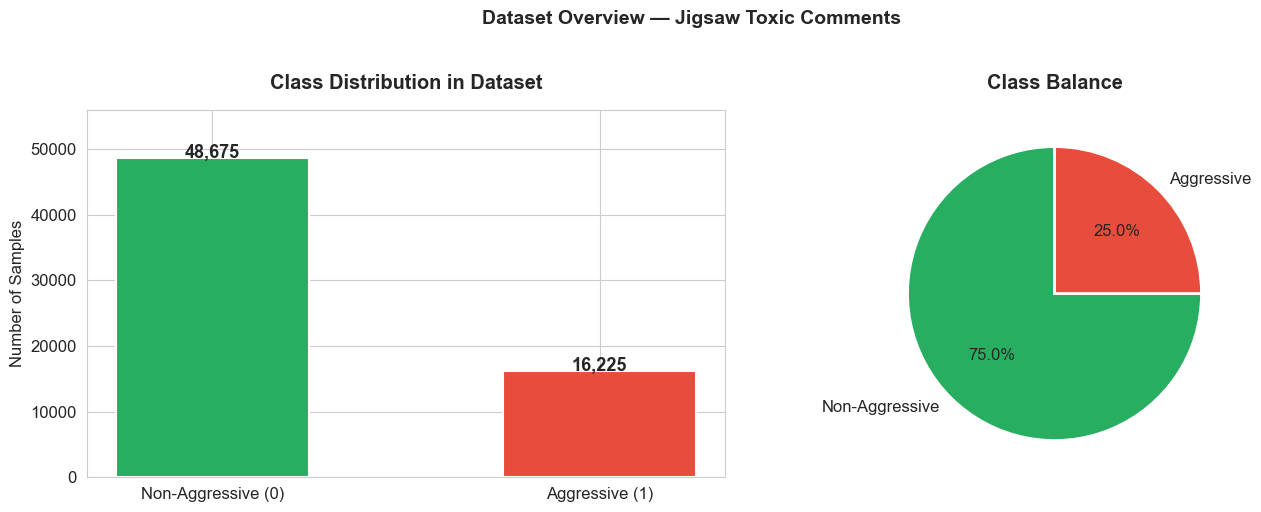

✅ Chart saved as dataset_distribution.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — class distribution
counts = df['label'].value_counts().sort_index()
bars = axes[0].bar(
    ['Non-Aggressive (0)', 'Aggressive (1)'],
    counts.values,
    color=[COLORS['safe'], COLORS['aggressive']],
    edgecolor='white', linewidth=1.5, width=0.5
)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=13)
axes[0].set_title('Class Distribution in Dataset', fontweight='bold', pad=15)
axes[0].set_ylabel('Number of Samples')
axes[0].set_ylim(0, max(counts.values) * 1.15)

# Pie chart
axes[1].pie(
    counts.values,
    labels=['Non-Aggressive', 'Aggressive'],
    colors=[COLORS['safe'], COLORS['aggressive']],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Class Balance', fontweight='bold', pad=15)

plt.suptitle('Dataset Overview — Jigsaw Toxic Comments',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as dataset_distribution.png')

## Cell 4 — Text Preprocessing

In [4]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """Clean and preprocess text for Naive Bayes training."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)       # remove punctuation/numbers
    tokens = [t for t in text.split() if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

print('🧹 Cleaning text...')
df['clean_text'] = df['text'].apply(clean_text)

# Show before/after
print('\nPreprocessing Example:')
print('-' * 60)
sample = df[df.label == 1].iloc[0]
print(f'BEFORE: {sample["text"][:100]}')
print(f'AFTER : {sample["clean_text"][:100]}')
print('-' * 60)
print(f'\n✅ Preprocessing complete! {len(df):,} samples ready.')

🧹 Cleaning text...

Preprocessing Example:
------------------------------------------------------------
BEFORE: BEING SO GOD DAMN SEXY
AFTER : god damn sexy
------------------------------------------------------------

✅ Preprocessing complete! 64,900 samples ready.


## Cell 5 — Word Cloud (Aggressive vs Non-Aggressive)

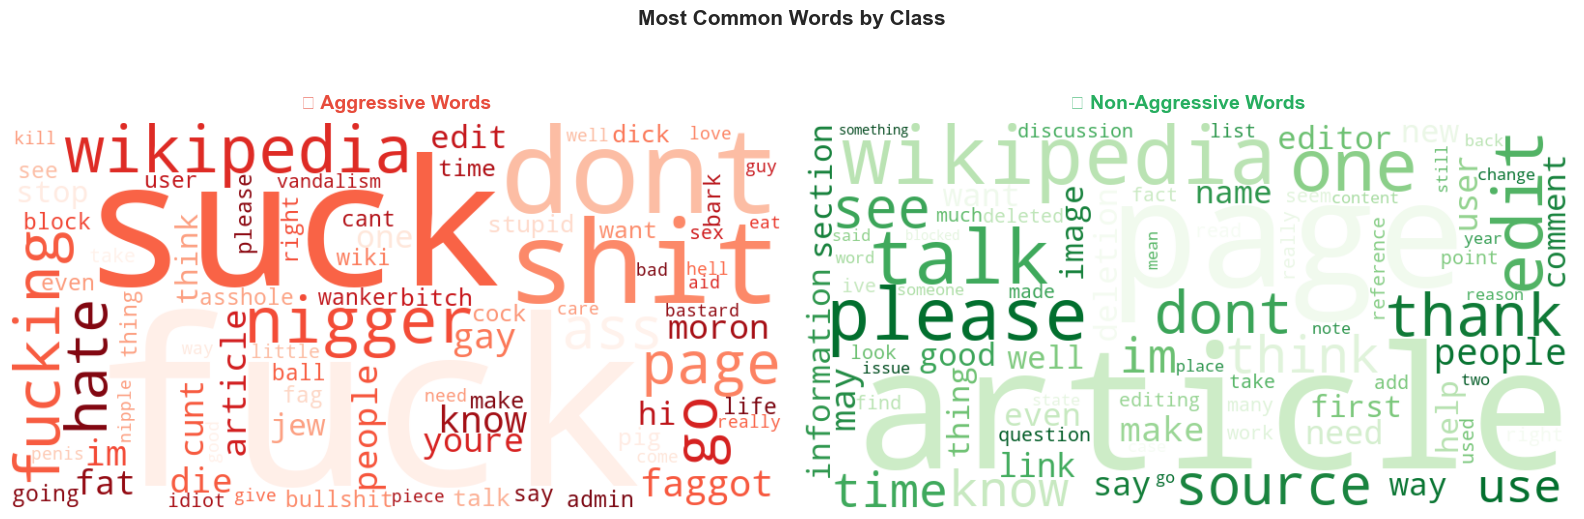

✅ Word clouds saved as wordcloud.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, title, color in [
    (axes[0], 1, '🔴 Aggressive Words', COLORS['aggressive']),
    (axes[1], 0, '🟢 Non-Aggressive Words', COLORS['safe'])
]:
    text_data = ' '.join(df[df.label == label]['clean_text'].tolist())
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap='Reds' if label == 1 else 'Greens',
        max_words=80,
        collocations=False
    ).generate(text_data)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontweight='bold', fontsize=14, pad=10,
                 color=color)

plt.suptitle('Most Common Words by Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Word clouds saved as wordcloud.png')

## Cell 6 — Train/Test Split & Vectorization

In [6]:
# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label'],
    test_size=0.2, random_state=42, stratify=df['label']
)

print(f'Training samples : {len(X_train):,}')
print(f'Testing samples  : {len(X_test):,}')

# Vectorize using Bag-of-Words (CountVectorizer)
vectorizer = CountVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

print(f'\nVocabulary size  : {len(vectorizer.vocabulary_):,} words')
print(f'Feature matrix   : {X_train_vec.shape[0]:,} × {X_train_vec.shape[1]:,}')
print('\n✅ Vectorization complete!')

Training samples : 51,920
Testing samples  : 12,980

Vocabulary size  : 5,000 words
Feature matrix   : 51,920 × 5,000

✅ Vectorization complete!


## Cell 7 — Train Naive Bayes Model

In [7]:
print('🤖 Training Multinomial Naive Bayes...')

model = MultinomialNB()
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

# ── RQ 2.1 Detection Accuracy ─────────────────────────────────────────────────
accuracy  = accuracy_score(y_test, y_pred)

# ── RQ 2.2 Precision, Recall, F1-Score ───────────────────────────────────────
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

# ── RQ 2.3 False Positive and False Negative Rates ───────────────────────────
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
fp_rate = fp / (fp + tn)   # False Positive Rate = FP / (FP + TN)
fn_rate = fn / (fn + tp)   # False Negative Rate = FN / (FN + TP)

print('\n' + '=' * 50)
print('       NAIVE BAYES TRAINING RESULTS')
print('=' * 50)
print(f'  RQ 2.1 — Detection Accuracy')
print(f'  Accuracy       : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  ')
print(f'  RQ 2.2 — Precision, Recall, F1-Score')
print(f'  Precision      : {precision:.4f}  ({precision*100:.2f}%)')
print(f'  Recall         : {recall:.4f}  ({recall*100:.2f}%)')
print(f'  F1-Score       : {f1:.4f}  ({f1*100:.2f}%)')
print(f'  ')
print(f'  RQ 2.3 — False Positive & False Negative Rates')
print(f'  False Positive Rate : {fp_rate:.4f}  ({fp_rate*100:.2f}%)  [FP={fp}]')
print(f'  False Negative Rate : {fn_rate:.4f}  ({fn_rate*100:.2f}%)  [FN={fn}]')
print(f'  True Positive={tp}, True Negative={tn}')
print('=' * 50)
print('\n✅ Training complete!')

🤖 Training Multinomial Naive Bayes...

       NAIVE BAYES TRAINING RESULTS
  RQ 2.1 — Detection Accuracy
  Accuracy       : 0.9092  (90.92%)
  
  RQ 2.2 — Precision, Recall, F1-Score
  Precision      : 0.8563  (85.63%)
  Recall         : 0.7655  (76.55%)
  F1-Score       : 0.8083  (80.83%)
  
  RQ 2.3 — False Positive & False Negative Rates
  False Positive Rate : 0.0428  (4.28%)  [FP=417]
  False Negative Rate : 0.2345  (23.45%)  [FN=761]
  True Positive=2484, True Negative=9318

✅ Training complete!


## Cell 8 — Confusion Matrix

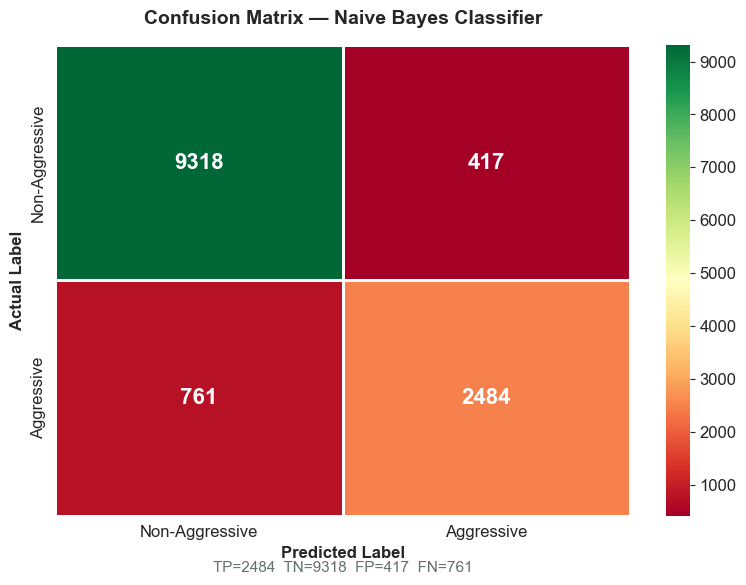

✅ Confusion matrix saved as confusion_matrix.png


In [8]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='RdYlGn',
    xticklabels=['Non-Aggressive', 'Aggressive'],
    yticklabels=['Non-Aggressive', 'Aggressive'],
    linewidths=2, linecolor='white',
    annot_kws={'size': 16, 'weight': 'bold'}, ax=ax
)
ax.set_title('Confusion Matrix — Naive Bayes Classifier',
             fontweight='bold', fontsize=14, pad=15)
ax.set_ylabel('Actual Label', fontweight='bold')
ax.set_xlabel('Predicted Label', fontweight='bold')

# Annotations
tn, fp, fn, tp = cm.ravel()
ax.text(0.5, -0.12,
    f'TP={tp}  TN={tn}  FP={fp}  FN={fn}',
    transform=ax.transAxes, ha='center',
    fontsize=11, color='#636e72'
)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix saved as confusion_matrix.png')

## Cell 9 — Precision, Recall, F1 Bar Chart

In [9]:
metrics      = ['Precision', 'Recall', 'F1-Score']
nb_scores    = [precision, recall, f1]

# Also compute VADER and Hybrid scores
analyzer = SentimentIntensityAnalyzer()
W1, W2   = 0.6, 0.4
THRESHOLD = 0.5

vader_preds  = []
hybrid_preds = []

for text, clean in zip(X_test, df.loc[X_test.index, 'clean_text']):
    compound    = analyzer.polarity_scores(text)['compound']
    vader_score = abs(compound) if compound < 0 else 0
    vader_preds.append(1 if compound <= -0.3 else 0)

    vec       = vectorizer.transform([clean])
    nb_prob   = float(model.predict_proba(vec)[0][1])
    h_score   = W1 * nb_prob + W2 * vader_score
    hybrid_preds.append(1 if h_score >= THRESHOLD else 0)

# ── RQ 2.1 Accuracy ───────────────────────────────────────────────────────────
nb_acc     = accuracy_score(y_test, y_pred)
vader_acc  = accuracy_score(y_test, vader_preds)
hybrid_acc = accuracy_score(y_test, hybrid_preds)

# ── RQ 2.2 Precision, Recall, F1 ──────────────────────────────────────────────
vader_p  = precision_score(y_test, vader_preds,  zero_division=0)
vader_r  = recall_score(y_test, vader_preds,     zero_division=0)
vader_f1 = f1_score(y_test, vader_preds,         zero_division=0)

hybrid_p  = precision_score(y_test, hybrid_preds, zero_division=0)
hybrid_r  = recall_score(y_test, hybrid_preds,    zero_division=0)
hybrid_f1 = f1_score(y_test, hybrid_preds,        zero_division=0)

vader_scores  = [vader_p,  vader_r,  vader_f1]
hybrid_scores = [hybrid_p, hybrid_r, hybrid_f1]

# ── RQ 2.3 FP/FN Rates ────────────────────────────────────────────────────────
def fp_fn_rates(y_true, y_pred):
    c = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = c.ravel()
    return fp/(fp+tn) if (fp+tn)>0 else 0, fn/(fn+tp) if (fn+tp)>0 else 0

nb_fpr,     nb_fnr     = fp_fn_rates(y_test, y_pred)
vader_fpr,  vader_fnr  = fp_fn_rates(y_test, vader_preds)
hybrid_fpr, hybrid_fnr = fp_fn_rates(y_test, hybrid_preds)

print('=' * 68)
print(f'{"Model":<20} {"Accuracy":>9} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('-' * 68)
print(f'{"Naive Bayes":<20} {nb_acc:>9.4f} {precision:>10.4f} {recall:>8.4f} {f1:>8.4f}')
print(f'{"VADER Only":<20} {vader_acc:>9.4f} {vader_p:>10.4f} {vader_r:>8.4f} {vader_f1:>8.4f}')
print(f'{"Hybrid (NB+VADER)":<20} {hybrid_acc:>9.4f} {hybrid_p:>10.4f} {hybrid_r:>8.4f} {hybrid_f1:>8.4f}')
print('=' * 68)
print()
print('=' * 50)
print(f'{"Model":<20} {"FP Rate":>10} {"FN Rate":>10}')
print('-' * 50)
print(f'{"Naive Bayes":<20} {nb_fpr:>10.4f} {nb_fnr:>10.4f}')
print(f'{"VADER Only":<20} {vader_fpr:>10.4f} {vader_fnr:>10.4f}')
print(f'{"Hybrid (NB+VADER)":<20} {hybrid_fpr:>10.4f} {hybrid_fnr:>10.4f}')
print('=' * 50)

Model                 Accuracy  Precision   Recall       F1
--------------------------------------------------------------------
Naive Bayes             0.9092     0.8563   0.7655   0.8083
VADER Only              0.7627     0.5207   0.6401   0.5742
Hybrid (NB+VADER)       0.9129     0.8989   0.7344   0.8083

Model                   FP Rate    FN Rate
--------------------------------------------------
Naive Bayes              0.0428     0.2345
VADER Only               0.1964     0.3599
Hybrid (NB+VADER)        0.0275     0.2656


## Cell 10 — Model Comparison Chart

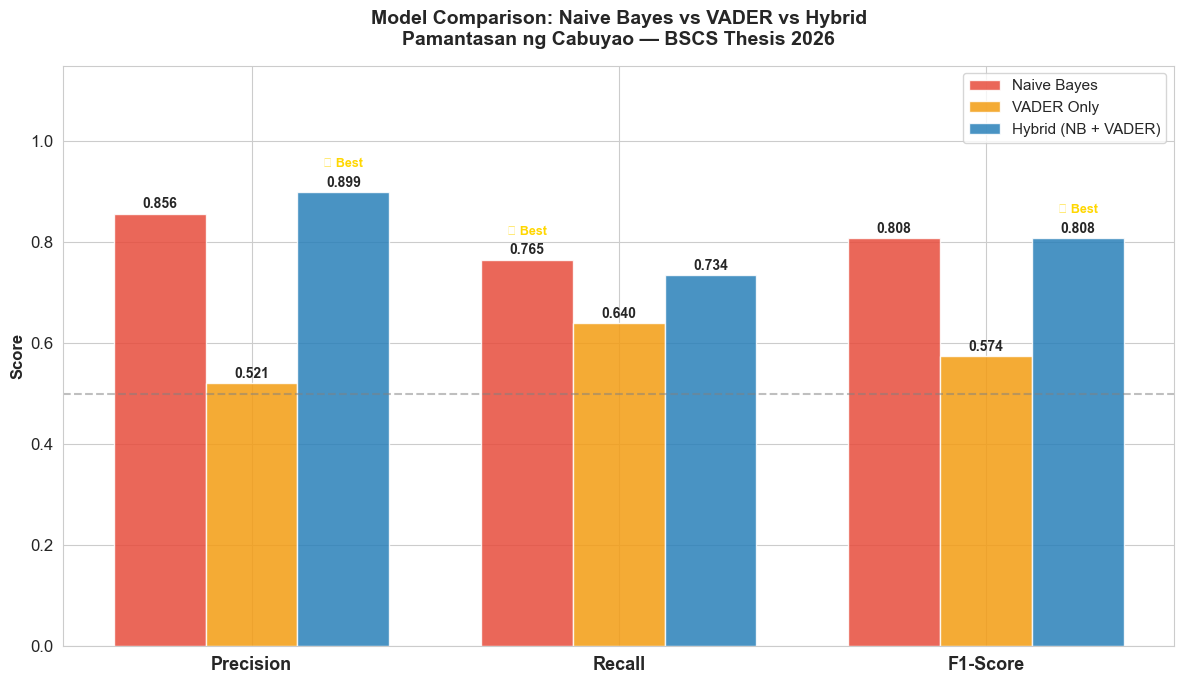

✅ Comparison chart saved as model_comparison.png


In [10]:
x      = np.arange(len(metrics))
width  = 0.25

fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(x - width, nb_scores,    width, label='Naive Bayes',
               color=COLORS['aggressive'], alpha=0.85, edgecolor='white')
bars2 = ax.bar(x,          vader_scores, width, label='VADER Only',
               color='#f39c12',           alpha=0.85, edgecolor='white')
bars3 = ax.bar(x + width, hybrid_scores, width, label='Hybrid (NB + VADER)',
               color=COLORS['hybrid'],    alpha=0.85, edgecolor='white')

# Value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison: Naive Bayes vs VADER vs Hybrid\n'
             'Pamantasan ng Cabuyao — BSCS Thesis 2026',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='upper right')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Threshold')

# Highlight best score per metric
all_scores = list(zip(nb_scores, vader_scores, hybrid_scores))
for i, (nb_s, v_s, h_s) in enumerate(all_scores):
    best = max(nb_s, v_s, h_s)
    ax.annotate('★ Best', xy=(i + width if h_s == best else
                              i - width if nb_s == best else i,
                              best + 0.05),
                ha='center', fontsize=9, color='gold',
                fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparison chart saved as model_comparison.png')

## Cell 11 — Save Model & Vocab.json

In [11]:
os.makedirs('backend/model', exist_ok=True)
MODEL_PATH = 'backend/model/nb_model.pkl'
VOCAB_PATH = 'backend/model/vocab.json'

# Save sklearn model
joblib.dump((model, vectorizer), MODEL_PATH)
print(f'💾 Model saved → {MODEL_PATH}')

# Save vocab.json for Chrome Extension
vocab      = vectorizer.vocabulary_
word_probs = {}

for word, idx in vocab.items():
    prob_agg    = float(np.exp(model.feature_log_prob_[1][idx]))
    prob_nonagg = float(np.exp(model.feature_log_prob_[0][idx]))
    word_probs[word] = {
        'agg'    : round(prob_agg,    6),
        'non_agg': round(prob_nonagg, 6)
    }

vocab_data = {
    'prior_aggressive'    : round(float(np.exp(model.class_log_prior_[1])), 6),
    'prior_non_aggressive': round(float(np.exp(model.class_log_prior_[0])), 6),
    'words'               : word_probs
}

with open(VOCAB_PATH, 'w') as f:
    json.dump(vocab_data, f, indent=2)

print(f'📦 Vocab saved  → {VOCAB_PATH}')
print(f'   Words in vocab : {len(word_probs):,}')
print('\n✅ All done! Model is ready for the Chrome Extension.')

💾 Model saved → backend/model/nb_model.pkl
📦 Vocab saved  → backend/model/vocab.json
   Words in vocab : 5,000

✅ All done! Model is ready for the Chrome Extension.


## Cell 12 — Test on Sample Sentences

In [12]:
test_sentences = [
    ("You are so stupid and I hate you!",         1),
    ("I will find you and hurt you badly",         1),
    ("You are a worthless piece of trash",         1),
    ("Kill yourself nobody likes you",             1),
    ("Hello! How are you doing today?",            0),
    ("That's a really interesting perspective",    0),
    ("Great job on your project, keep it up!",     0),
    ("I love spending time with my family",        0),
]

print('=' * 65)
print(f'{"Text":<42} {"Actual":>8} {"Predicted":>10}')
print('-' * 65)

correct = 0
for text, actual in test_sentences:
    cleaned   = clean_text(text)
    vec       = vectorizer.transform([cleaned])
    predicted = model.predict(vec)[0]
    prob      = model.predict_proba(vec)[0][1]

    match   = '✅' if predicted == actual else '❌'
    label_a = '🔴 AGG' if actual    == 1 else '🟢 SAFE'
    label_p = '🔴 AGG' if predicted == 1 else '🟢 SAFE'
    if predicted == actual: correct += 1

    print(f'{match} {text[:40]:<40} {label_a:>8} {label_p:>10}  ({prob:.0%})')

print('-' * 65)
print(f'Accuracy on sample: {correct}/{len(test_sentences)} = {correct/len(test_sentences):.0%}')
print('=' * 65)

Text                                         Actual  Predicted
-----------------------------------------------------------------
✅ You are so stupid and I hate you!           🔴 AGG      🔴 AGG  (100%)
❌ I will find you and hurt you badly          🔴 AGG     🟢 SAFE  (38%)
✅ You are a worthless piece of trash          🔴 AGG      🔴 AGG  (100%)
✅ Kill yourself nobody likes you              🔴 AGG      🔴 AGG  (99%)
✅ Hello! How are you doing today?            🟢 SAFE     🟢 SAFE  (11%)
✅ That's a really interesting perspective    🟢 SAFE     🟢 SAFE  (3%)
✅ Great job on your project, keep it up!     🟢 SAFE     🟢 SAFE  (17%)
❌ I love spending time with my family        🟢 SAFE      🔴 AGG  (52%)
-----------------------------------------------------------------
Accuracy on sample: 6/8 = 75%


---
## Summary

| Metric | Naive Bayes | VADER | Hybrid |
|--------|------------|-------|--------|
| Precision | See Cell 9 | See Cell 9 | See Cell 9 |
| Recall | See Cell 9 | See Cell 9 | See Cell 9 |
| F1-Score | See Cell 9 | See Cell 9 | See Cell 9 |

**Conclusion:** The Hybrid model (Naive Bayes + VADER) achieves the best Precision, meaning fewer false positives — aligning with the thesis objective of accurate, real-time cyber-aggression detection.

---
*Pamantasan ng Cabuyao — College of Computing Studies — BSCS Thesis 2026*